# XGBoost Waste Forecasting (Multi-Meal)

In [4]:
!pip install optuna


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [5]:
# 1. Import Libraries
import os
import pickle
import warnings
import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

warnings.filterwarnings('ignore')
os.makedirs('models/xgboost_optimized', exist_ok=True)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
optuna.logging.set_verbosity(optuna.logging.WARNING)

MEALS = ['breakfast', 'lunch', 'dinner']  # target meals (exclude 'closed')
TARGET = 'waste_kg'

In [6]:
# # Change to your own directory
# try:
#     import os
#     from google.colab import drive
#     drive.mount('/content/drive', force_remount=True)
#     os.chdir('/content/drive/MyDrive/UAB/FDS/campus-waste-intelligence')
#     print('Directory changed')
# except OSError:
#     print("Error: Can't change the Current Working Directory")

## 2. Load and Inspect Dataset

In [7]:
# Load dataset
df_raw = pd.read_csv('data/waste_features_xgb.csv')
print(f'Raw dataset shape: {df_raw.shape}')
print('Meal values:', df_raw['meal'].unique())

# Keep only the three operational meals
df_raw = df_raw[df_raw['meal'].isin(MEALS)].copy()
print(f'After filtering to breakfast/lunch/dinner: {df_raw.shape}')
df_raw.head()

Raw dataset shape: (2506, 33)
Meal values: <ArrowStringArray>
['lunch', 'breakfast', 'closed', 'dinner']
Length: 4, dtype: str
After filtering to breakfast/lunch/dinner: (1813, 33)


,meal,waste_kg,waste_organic_kg,waste_recyclable_kg,waste_landfill_kg,foot_traffic,is_holiday,has_special_event,year,month,...,lag_28,rolling_mean_7,rolling_mean_14,rolling_std_7,rolling_max_7,section_encoded,section_a,section_b,section_c,section_d
0,lunch,5.17,2.74,1.75,0.68,102.00,0,1,2025,1,...,0.18,2.262857,2.102857,2.249257,5.58,0,True,False,False,False
1,breakfast,4.26,1.74,1.27,1.24,46.25,0,1,2025,1,...,3.18,2.854286,2.396429,2.133197,5.58,0,True,False,False,False
3,dinner,2.72,1.72,0.75,0.25,75.00,0,1,2025,1,...,0.06,2.147143,2.390000,1.978819,5.17,0,True,False,False,False
4,lunch,6.07,3.12,2.06,0.89,138.00,0,1,2025,1,...,1.50,2.842857,2.810000,2.401317,6.07,0,True,False,False,False
5,breakfast,2.96,1.21,0.89,0.85,46.00,0,1,2025,1,...,1.82,3.244286,2.786429,2.090940,6.07,0,True,False,False,False


## 3. Preprocess Data

- Build a proper `date` column from year/month/day.
- Sort by section, date, and meal_type.
- Recompute lag and rolling features **grouped by (section, meal_type)** so each meal stream has its own temporal context.
- Encode `meal_type` as a categorical feature for XGBoost.
- Split into per-section DataFrames.

In [8]:
# Build date column from year/month/day
df_raw['date'] = pd.to_datetime(df_raw[['year', 'month', 'day']])

# Identify the section for each row
sections = ['a', 'b', 'c', 'd']
def get_section_label(row):
    for s in sections:
        if row[f'section_{s}']:
            return s
    return None

df_raw['section'] = df_raw.apply(get_section_label, axis=1)

# Rename 'meal' to 'meal_type' for clarity
df_raw = df_raw.rename(columns={'meal': 'meal_type'})

# Sort so that groupby-shift produces correct temporal order
df_raw = df_raw.sort_values(['section', 'date', 'meal_type']).reset_index(drop=True)

# --- Recompute lag and rolling features per (section, meal_type) ---
# This ensures each meal stream has its own lag context
group_key = ['section', 'meal_type']

for lag in [1, 7, 14, 28]:
    df_raw[f'lag_{lag}'] = df_raw.groupby(group_key)[TARGET].shift(lag)

df_raw['rolling_mean_7']  = df_raw.groupby(group_key)[TARGET].transform(lambda x: x.shift(1).rolling(7,  min_periods=1).mean())
df_raw['rolling_mean_14'] = df_raw.groupby(group_key)[TARGET].transform(lambda x: x.shift(1).rolling(14, min_periods=1).mean())
df_raw['rolling_std_7']   = df_raw.groupby(group_key)[TARGET].transform(lambda x: x.shift(1).rolling(7,  min_periods=1).std().fillna(0))
df_raw['rolling_max_7']   = df_raw.groupby(group_key)[TARGET].transform(lambda x: x.shift(1).rolling(7,  min_periods=1).max())

# Drop rows where any lag is NaN (first few rows per group)
df_raw = df_raw.dropna(subset=[f'lag_{l}' for l in [1, 7, 14, 28]]).reset_index(drop=True)
print(f'After preprocessing: {df_raw.shape}')

# Split by section; drop section indicator columns
section_data = {}
drop_cols = [f'section_{s}' for s in sections] + ['section_encoded', 'section']
for sec in sections:
    sec_df = df_raw[df_raw['section'] == sec].copy()
    sec_df = sec_df.drop(columns=drop_cols, errors='ignore')
    section_data[sec] = sec_df
    print(f'Section {sec.upper()}: {len(sec_df)} rows, {sec_df["meal_type"].value_counts().to_dict()}')

After preprocessing: (1477, 35)
Section A: 371 rows, {'dinner': 127, 'breakfast': 125, 'lunch': 119}
Section B: 372 rows, {'dinner': 130, 'breakfast': 125, 'lunch': 117}
Section C: 372 rows, {'dinner': 131, 'breakfast': 129, 'lunch': 112}
Section D: 362 rows, {'dinner': 131, 'breakfast': 124, 'lunch': 107}


## 4. Define Features and Target

`meal_type` is kept as a categorical feature. `date` is dropped before training.

In [9]:
def get_X_y_cleaned(data):
    """Drop non-feature columns and encode categoricals for XGBoost."""
    X = data.drop(columns=[TARGET, 'date'], errors='ignore')
    y = data[TARGET]
    # Encode object/string columns as category dtype (XGBoost native support)
    for col in X.select_dtypes(include=['object', 'string']).columns:
        X[col] = X[col].astype('category')
    return X, y

# Inspect feature set for section A
X_a, y_a = get_X_y_cleaned(section_data['a'])
print(f'Features shape: {X_a.shape}')
print('Feature columns:', list(X_a.columns))

Features shape: (371, 27)
Feature columns: ['meal_type', 'waste_organic_kg', 'waste_recyclable_kg', 'waste_landfill_kg', 'foot_traffic', 'is_holiday', 'has_special_event', 'year', 'month', 'day', 'day_of_week', 'day_of_year', 'week_of_year', 'quarter', 'is_weekend', 'dow_sin', 'dow_cos', 'doy_sin', 'doy_cos', 'lag_1', 'lag_7', 'lag_14', 'lag_28', 'rolling_mean_7', 'rolling_mean_14', 'rolling_std_7', 'rolling_max_7']


## 5. Time-Based Train-Test Split

We reserve the last **30 days** (i.e. up to 90 rows — 3 meals × 30 days) for testing.
The split is done on unique dates so all meals of a given day stay in the same partition.

In [10]:
TEST_DAYS = 30  # last 30 calendar days held out

splits = {}
for sec in sections:
    data = section_data[sec].sort_values('date').reset_index(drop=True)
    unique_dates = data['date'].drop_duplicates().sort_values()
    cutoff_date = unique_dates.iloc[-TEST_DAYS]  # first date of the test window
    train = data[data['date'] < cutoff_date].copy()
    test  = data[data['date'] >= cutoff_date].copy()
    splits[sec] = {'train': train, 'test': test}
    print(f'Section {sec.upper()} | Train: {len(train)} rows ({train["date"].nunique()} days) | '
          f'Test: {len(test)} rows ({test["date"].nunique()} days)')

Section A | Train: 292 rows (113 days) | Test: 79 rows (30 days)
Section B | Train: 294 rows (113 days) | Test: 78 rows (30 days)
Section C | Train: 297 rows (112 days) | Test: 75 rows (30 days)
Section D | Train: 288 rows (112 days) | Test: 74 rows (30 days)


## 6. Baseline Model (Default XGBoost)

Train with default parameters to establish a performance reference.

In [20]:
def evaluate_model(model, X_test, y_test):
    pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae  = mean_absolute_error(y_test, pred)
    mape = np.mean(np.abs((y_test - pred) / np.where(y_test == 0, 1e-9, y_test))) * 100
    r2   = r2_score(y_test, pred)
    return rmse, mae, mape, r2


def evaluate_by_meal(model, test_data):
    """Return per-meal metrics as a list of dicts."""
    rows = []
    for meal in MEALS:
        meal_df = test_data[test_data['meal_type'] == meal]
        if len(meal_df) == 0:
            continue
        X_m, y_m = get_X_y_cleaned(meal_df)
        rmse, mae, mape, r2 = evaluate_model(model, X_m, y_m)
        rows.append({'meal': meal, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'R2': r2})
    return rows


baseline_results = []
for sec in sections:
    train = splits[sec]['train']
    test  = splits[sec]['test']
    X_train, y_train = get_X_y_cleaned(train)
    X_test,  y_test  = get_X_y_cleaned(test)

    bl_model = xgb.XGBRegressor(
        objective='reg:squarederror',
        random_state=RANDOM_SEED,
        verbosity=0,
        enable_categorical=True
    )
    bl_model.fit(X_train, y_train)

    # Overall metrics
    rmse, mae, mape, r2 = evaluate_model(bl_model, X_test, y_test)
    baseline_results.append({'section': sec.upper(), 'meal': 'overall', 'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'R2': r2})

    # Per-meal metrics
    for row in evaluate_by_meal(bl_model, test):
        row['section'] = sec.upper()
        baseline_results.append(row)

baseline_df = pd.DataFrame(baseline_results)
print('Baseline Performance')
print(baseline_df.to_string(index=False))

Baseline Performance
section      meal     RMSE      MAE     MAPE       R2
      A   overall 0.223689 0.114864 2.892394 0.990980
      A breakfast 0.078427 0.060133 2.671874 0.996767
      A     lunch 0.303077 0.165990 3.417465 0.987089
      A    dinner 0.252349 0.132789 2.682354 0.988680
      B   overall 0.879655 0.299781 4.981065 0.944194
      B breakfast 0.125931 0.095517 4.784489 0.990388
      B     lunch 1.453138 0.502190 5.004201 0.902634
      B    dinner 0.425667 0.286914 5.128075 0.970322
      C   overall 0.335762 0.171567 3.795438 0.987191
      C breakfast 0.101547 0.084233 3.581813 0.996445
      C     lunch 0.556100 0.305854 4.100157 0.975109
      C    dinner 0.172705 0.131584 3.719568 0.993705
      D   overall 0.452837 0.182443 3.097907 0.977881
      D breakfast 0.389218 0.161363 3.482312 0.958496
      D     lunch 0.693832 0.321063 3.876489 0.962235
      D    dinner 0.110073 0.080088 2.039541 0.997452


## 7. Evaluation Metrics

Primary optimisation metric: **RMSE**. We also track MAE, MAPE, and R² overall and per meal.

## 8. Cross-Validation and Adaptive Hyperparameter Optimisation

**Optuna** Bayesian search with `TimeSeriesSplit` (5 folds).
Because each day has multiple rows (one per meal), `TimeSeriesSplit` splits on row index which naturally preserves temporal order within each section.

Search space: `n_estimators`, `max_depth`, `learning_rate`, `subsample`, `colsample_bytree`, `reg_lambda`, `reg_alpha`, `min_child_weight`.

Up to 50 trials per section.

In [12]:
def objective(trial, X_train, y_train, cv_splits=5):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 1000, step=50),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 10),
        'objective':         'reg:squarederror',
        'random_state':      RANDOM_SEED,
        'verbosity':         0,
        'enable_categorical': True,
    }

    # TimeSeriesSplit respects row order; multi-meal rows are already sorted by date
    tscv = TimeSeriesSplit(n_splits=cv_splits)
    rmse_scores = []

    for train_idx, val_idx in tscv.split(X_train):
        X_tr,  X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr,  y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        model = xgb.XGBRegressor(**params)
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
        pred = model.predict(X_val)
        rmse_scores.append(np.sqrt(mean_squared_error(y_val, pred)))

    return np.mean(rmse_scores)


N_TRIALS = 50
best_models = {}
study_logs  = {}

for sec in sections:
    print(f"\nOptimising Section {sec.upper()}\n")
    train = splits[sec]['train']
    X_train, y_train = get_X_y_cleaned(train)

    study = optuna.create_study(
        direction='minimize',
        sampler=TPESampler(seed=RANDOM_SEED),
        pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=10)
    )

    def objective_wrapper(trial):
        return objective(trial, X_train, y_train)

    study.optimize(objective_wrapper, n_trials=N_TRIALS, show_progress_bar=True)
    study_logs[sec] = study.trials_dataframe()

    best_params = study.best_params
    print(f'Best parameters for section {sec.upper()}: {best_params}')

    # Train final model on full training set
    final_model = xgb.XGBRegressor(
        **best_params,
        objective='reg:squarederror',
        random_state=RANDOM_SEED,
        verbosity=0,
        enable_categorical=True
    )
    final_model.fit(X_train, y_train)
    best_models[sec] = final_model

    # Save model and params
    with open(f'models/xgboost_optimized/tuned_section_{sec}.pkl', 'wb') as f:
        pickle.dump(final_model, f)
    with open(f'models/xgboost_optimized/best_params_section_{sec}.pkl', 'wb') as f:
        pickle.dump(best_params, f)

    # Quick test-set evaluation
    test = splits[sec]['test']
    X_test, y_test = get_X_y_cleaned(test)
    rmse, mae, mape, r2 = evaluate_model(final_model, X_test, y_test)
    print(f'Test set performance - RMSE: {rmse:.4f}, MAE: {mae:.4f}, MAPE: {mape:.2f}%, R2: {r2:.4f}')

print('\nOptimisation completed for all sections.')


Optimising Section A


Best trial: 42. Best value: 0.359843: 100%|██████████| 50/50 [02:57<00:00,  3.56s/it]


Best parameters for section A: {'n_estimators': 950, 'max_depth': 9, 'learning_rate': 0.056208111738860346, 'subsample': 0.6454293548907892, 'colsample_bytree': 0.9183945066241215, 'reg_lambda': 0.5597246284055408, 'reg_alpha': 0.001611631943664484, 'min_child_weight': 2}
Test set performance - RMSE: 0.1858, MAE: 0.0944, MAPE: 2.24%, R2: 0.9938

Optimising Section B


Best trial: 49. Best value: 0.196427: 100%|██████████| 50/50 [02:55<00:00,  3.51s/it]


Best parameters for section B: {'n_estimators': 700, 'max_depth': 9, 'learning_rate': 0.010309754938756096, 'subsample': 0.6252506348914477, 'colsample_bytree': 0.8227388956734512, 'reg_lambda': 0.004505241716510253, 'reg_alpha': 0.01086031327227575, 'min_child_weight': 1}
Test set performance - RMSE: 0.8524, MAE: 0.2226, MAPE: 3.16%, R2: 0.9476

Optimising Section C


Best trial: 35. Best value: 0.348078: 100%|██████████| 50/50 [02:34<00:00,  3.10s/it]


Best parameters for section C: {'n_estimators': 650, 'max_depth': 6, 'learning_rate': 0.04104437222141519, 'subsample': 0.699244765865553, 'colsample_bytree': 0.8594777475576882, 'reg_lambda': 0.007992479104126211, 'reg_alpha': 0.3234442144206603, 'min_child_weight': 1}
Test set performance - RMSE: 0.2839, MAE: 0.1382, MAPE: 2.90%, R2: 0.9908

Optimising Section D


Best trial: 23. Best value: 0.285254: 100%|██████████| 50/50 [02:47<00:00,  3.35s/it]


Best parameters for section D: {'n_estimators': 900, 'max_depth': 4, 'learning_rate': 0.022822527338608036, 'subsample': 0.8615888857369538, 'colsample_bytree': 0.9861491002170512, 'reg_lambda': 4.109769498728061, 'reg_alpha': 0.003637331048458448, 'min_child_weight': 1}
Test set performance - RMSE: 0.4192, MAE: 0.1546, MAPE: 2.66%, R2: 0.9810

Optimisation completed for all sections.


## 9. Final Performance Comparison

Compare baseline vs tuned models overall and broken down by meal type.

In [13]:
final_results = []

for sec in sections:
    test = splits[sec]['test']
    X_test, y_test = get_X_y_cleaned(test)

    # Baseline
    with open(f'models/xgboost_optimized/baseline_section_{sec}.pkl', 'rb') as f:
        baseline_model = pickle.load(f)
    b_rmse, b_mae, b_mape, b_r2 = evaluate_model(baseline_model, X_test, y_test)

    # Tuned
    tuned_model = best_models[sec]
    t_rmse, t_mae, t_mape, t_r2 = evaluate_model(tuned_model, X_test, y_test)

    for model_name, rmse, mae, mape, r2 in [
        ('Baseline',       b_rmse, b_mae, b_mape, b_r2),
        ('Tuned (Optuna)', t_rmse, t_mae, t_mape, t_r2),
    ]:
        final_results.append({'section': sec.upper(), 'model': model_name, 'meal': 'overall',
                               'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'R2': r2})

    for row in evaluate_by_meal(tuned_model, test):
        row.update({'section': sec.upper(), 'model': 'Tuned (Optuna)'})
        final_results.append(row)

results_df = pd.DataFrame(final_results)
print('Final Performance Comparison')
print(results_df.to_string(index=False))

results_df.to_csv('metrics/xgboost_model_comparison.csv', index=False)
print('\nComparison saved to metrics/xgboost_model_comparison.csv')

Final Performance Comparison
section          model      meal     RMSE      MAE     MAPE       R2
      A       Baseline   overall 0.223689 0.114864 2.892394 0.990980
      A Tuned (Optuna)   overall 0.185764 0.094439 2.240109 0.993779
      A Tuned (Optuna) breakfast 0.064999 0.047198 2.042240 0.997779
      A Tuned (Optuna)     lunch 0.283575 0.149105 2.703289 0.988697
      A Tuned (Optuna)    dinner 0.169827 0.100589 2.058683 0.994873
      B       Baseline   overall 0.879655 0.299781 4.981065 0.944194
      B Tuned (Optuna)   overall 0.852400 0.222610 3.158802 0.947599
      B Tuned (Optuna) breakfast 0.062962 0.041761 2.146040 0.997597
      B Tuned (Optuna)     lunch 1.452304 0.462598 4.572115 0.902745
      B Tuned (Optuna)    dinner 0.249264 0.154779 2.714522 0.989823
      C       Baseline   overall 0.335762 0.171567 3.795438 0.987191
      C Tuned (Optuna)   overall 0.283932 0.138170 2.895680 0.990840
      C Tuned (Optuna) breakfast 0.083027 0.067969 2.740468 0.997624
     

## 10. Iterative 7-Day Forecast (Breakfast, Lunch, Dinner)

For each section we generate a 7-day forecast **per meal type**.
The iterative function maintains a separate rolling history for each (section, meal) stream so that lag and rolling features are updated correctly after each prediction.

In [14]:
def forecast_next_week_iterative(model, history_df, horizon=7, target_col='waste_kg'):
    """
    Generate a horizon-day forecast for each meal type in MEALS.

    history_df must contain columns: date, meal_type, target_col, and all
    feature columns used during training.

    Returns a dict: {meal_type: [pred_day1, ..., pred_day_horizon]}
    """
    MAX_LOOKBACK = 28  # matches lag_28
    forecasts = {meal: [] for meal in MEALS}

    history_df = history_df.sort_values(['date', 'meal_type']).reset_index(drop=True)
    last_date  = history_df['date'].max()

    # Maintain a per-meal history for lag/rolling recalculation
    meal_histories = {
        meal: history_df[history_df['meal_type'] == meal].copy()
        for meal in MEALS
    }

    for i in range(1, horizon + 1):
        next_date = last_date + pd.Timedelta(days=i)

        for meal in MEALS:
            meal_hist = meal_histories[meal]

            # Build a new row by copying the last known row's static features
            new_row = meal_hist.iloc[-1:].copy()
            new_row['date']        = next_date
            new_row[target_col]    = np.nan  # unknown — will be predicted
            new_row['meal_type']   = meal

            # Update temporal features
            new_row['year']        = next_date.year
            new_row['month']       = next_date.month
            new_row['day']         = next_date.day
            new_row['day_of_week'] = next_date.dayofweek
            new_row['day_of_year'] = next_date.dayofyear
            new_row['week_of_year']= int(next_date.isocalendar().week)
            new_row['quarter']     = next_date.quarter
            new_row['is_weekend']  = int(next_date.dayofweek >= 5)
            new_row['dow_sin']     = np.sin(2 * np.pi * next_date.dayofweek / 7)
            new_row['dow_cos']     = np.cos(2 * np.pi * next_date.dayofweek / 7)
            new_row['doy_sin']     = np.sin(2 * np.pi * next_date.dayofyear / 365)
            new_row['doy_cos']     = np.cos(2 * np.pi * next_date.dayofyear / 365)

            # Concatenate with recent history for feature recalculation
            temp = pd.concat(
                [meal_hist.iloc[-MAX_LOOKBACK:], new_row],
                ignore_index=True
            )

            # Recalculate lags and rolling stats on the combined temp frame
            for lag in [1, 7, 14, 28]:
                temp[f'lag_{lag}'] = temp[target_col].shift(lag)
            temp['rolling_mean_7']  = temp[target_col].shift(1).rolling(7,  min_periods=1).mean()
            temp['rolling_mean_14'] = temp[target_col].shift(1).rolling(14, min_periods=1).mean()
            temp['rolling_std_7']   = temp[target_col].shift(1).rolling(7,  min_periods=1).std().fillna(0)
            temp['rolling_max_7']   = temp[target_col].shift(1).rolling(7,  min_periods=1).max()

            # Predict on the last row (the new date)
            X_pred = temp.iloc[-1:].drop(columns=[target_col, 'date'], errors='ignore')
            for col in X_pred.select_dtypes(include=['object', 'string']).columns:
                X_pred[col] = X_pred[col].astype('category')

            predicted = float(model.predict(X_pred)[0])
            forecasts[meal].append(predicted)

            # Update meal history with the prediction so next iteration uses it
            new_row[target_col] = predicted
            meal_histories[meal] = pd.concat([meal_hist, new_row], ignore_index=True)

    return forecasts


# --- Run forecasts for all sections ---
weekly_forecasts = {}  # {section: {meal: [7 values]}}

for sec in sections:
    with open(f'models/xgboost_optimized/tuned_section_{sec}.pkl', 'rb') as f:
        model = pickle.load(f)

    train_history = splits[sec]['train']
    forecasts = forecast_next_week_iterative(model, train_history, horizon=7, target_col=TARGET)
    weekly_forecasts[sec.upper()] = forecasts

    print(f'\nSection {sec.upper()} 7-day forecast:')
    for meal, preds in forecasts.items():
        print(f'  {meal:10s}: {[round(p, 2) for p in preds]}')

# Save forecasts to CSV
forecast_rows = []
for sec, meal_dict in weekly_forecasts.items():
    for meal, preds in meal_dict.items():
        for day_idx, val in enumerate(preds, start=1):
            forecast_rows.append({'section': sec, 'meal_type': meal, 'day': f'Day_{day_idx}', 'forecast_kg': val})

forecast_df = pd.DataFrame(forecast_rows)
forecast_df.to_csv('weekly_forecasts.csv', index=False)
print('\nWeekly forecasts saved to weekly_forecasts.csv')


Section A 7-day forecast:
  breakfast : [1.38, 1.38, 1.39, 1.4, 1.39, 1.4, 1.38]
  lunch     : [5.62, 5.64, 5.65, 5.63, 5.63, 5.62, 5.62]
  dinner    : [1.64, 1.62, 1.64, 1.62, 1.65, 1.64, 1.64]

Section B 7-day forecast:
  breakfast : [2.56, 2.57, 2.57, 2.58, 2.58, 2.57, 2.58]
  lunch     : [6.05, 6.0, 5.94, 5.96, 5.93, 5.93, 5.97]
  dinner    : [7.94, 7.85, 7.85, 7.87, 7.89, 7.86, 7.86]

Section C 7-day forecast:
  breakfast : [4.22, 4.22, 4.21, 4.2, 4.22, 4.21, 4.21]
  lunch     : [12.69, 12.61, 12.65, 12.73, 12.64, 12.74, 12.71]
  dinner    : [10.47, 10.39, 10.45, 10.49, 10.49, 10.51, 10.46]

Section D 7-day forecast:
  breakfast : [0.98, 0.98, 0.99, 1.0, 0.99, 0.98, 0.98]
  lunch     : [2.05, 2.03, 2.06, 2.06, 2.05, 2.05, 2.06]
  dinner    : [2.44, 2.44, 2.43, 2.42, 2.43, 2.44, 2.43]

Weekly forecasts saved to weekly_forecasts.csv


## 11. Generalisation Check

Compare cross-validation RMSE vs test RMSE to detect overfitting.

In [15]:
print('=== Generalisation Check ===')
for sec in sections:
    best_val_rmse = study_logs[sec]['value'].min()
    test_rmse = results_df[
        (results_df['section'] == sec.upper()) &
        (results_df['model'] == 'Tuned (Optuna)') &
        (results_df['meal'] == 'overall')
    ]['RMSE'].values[0]
    diff = abs(best_val_rmse - test_rmse)
    status = 'Good generalisation.' if diff < 0.5 else 'Possible overfitting — consider more regularisation.'
    print(f'Section {sec.upper()} | CV RMSE: {best_val_rmse:.4f} | Test RMSE: {test_rmse:.4f} | Diff: {diff:.4f} -> {status}')

=== Generalisation Check ===
Section A | CV RMSE: 0.3598 | Test RMSE: 0.1858 | Diff: 0.1741 -> Good generalisation.
Section B | CV RMSE: 0.1964 | Test RMSE: 0.8524 | Diff: 0.6560 -> Possible overfitting — consider more regularisation.
Section C | CV RMSE: 0.3481 | Test RMSE: 0.2839 | Diff: 0.0641 -> Good generalisation.
Section D | CV RMSE: 0.2853 | Test RMSE: 0.4192 | Diff: 0.1340 -> Good generalisation.


## 12. Visualise Forecasts: Baseline vs Tuned, by Meal Type

Each subplot shows one section. Lines are coloured by model type and styled by meal.

In [16]:
all_forecasts_comparison = {}

for sec in sections:
    train_data = splits[sec]['train']

    with open(f'models/xgboost_optimized/baseline_section_{sec}.pkl', 'rb') as f:
        baseline_model = pickle.load(f)
    baseline_preds = forecast_next_week_iterative(baseline_model, train_data.copy(), horizon=7, target_col=TARGET)

    with open(f'models/xgboost_optimized/tuned_section_{sec}.pkl', 'rb') as f:
        tuned_model = pickle.load(f)
    tuned_preds = forecast_next_week_iterative(tuned_model, train_data.copy(), horizon=7, target_col=TARGET)

    all_forecasts_comparison[sec.upper()] = {'Baseline': baseline_preds, 'Tuned': tuned_preds}

print('Forecasts generated for all sections (Baseline and Tuned).')

Forecasts generated for all sections (Baseline and Tuned).


In [17]:
last_train_date = splits['a']['train']['date'].max()
forecast_dates  = pd.date_range(start=last_train_date + pd.Timedelta(days=1), periods=7)

plot_rows = []
for sec, model_dict in all_forecasts_comparison.items():
    for model_name, meal_dict in model_dict.items():
        for meal, preds in meal_dict.items():
            for date, val in zip(forecast_dates, preds):
                plot_rows.append({
                    'Date': date,
                    'Section': sec,
                    'Model': model_name,
                    'Meal': meal,
                    'Forecast': val
                })

forecast_df_plot = pd.DataFrame(plot_rows)
display(forecast_df_plot.head(12))

,Date,Section,Model,Meal,Forecast
0,2025-06-01,A,Baseline,breakfast,1.402753
1,2025-06-02,A,Baseline,breakfast,1.375954
2,2025-06-03,A,Baseline,breakfast,1.405822
3,2025-06-04,A,Baseline,breakfast,1.398040
4,2025-06-05,A,Baseline,breakfast,1.409191
5,2025-06-06,A,Baseline,breakfast,1.397169
6,2025-06-07,A,Baseline,breakfast,1.396546
7,2025-06-01,A,Baseline,lunch,5.475279
8,2025-06-02,A,Baseline,lunch,5.494745
9,2025-06-03,A,Baseline,lunch,5.613433


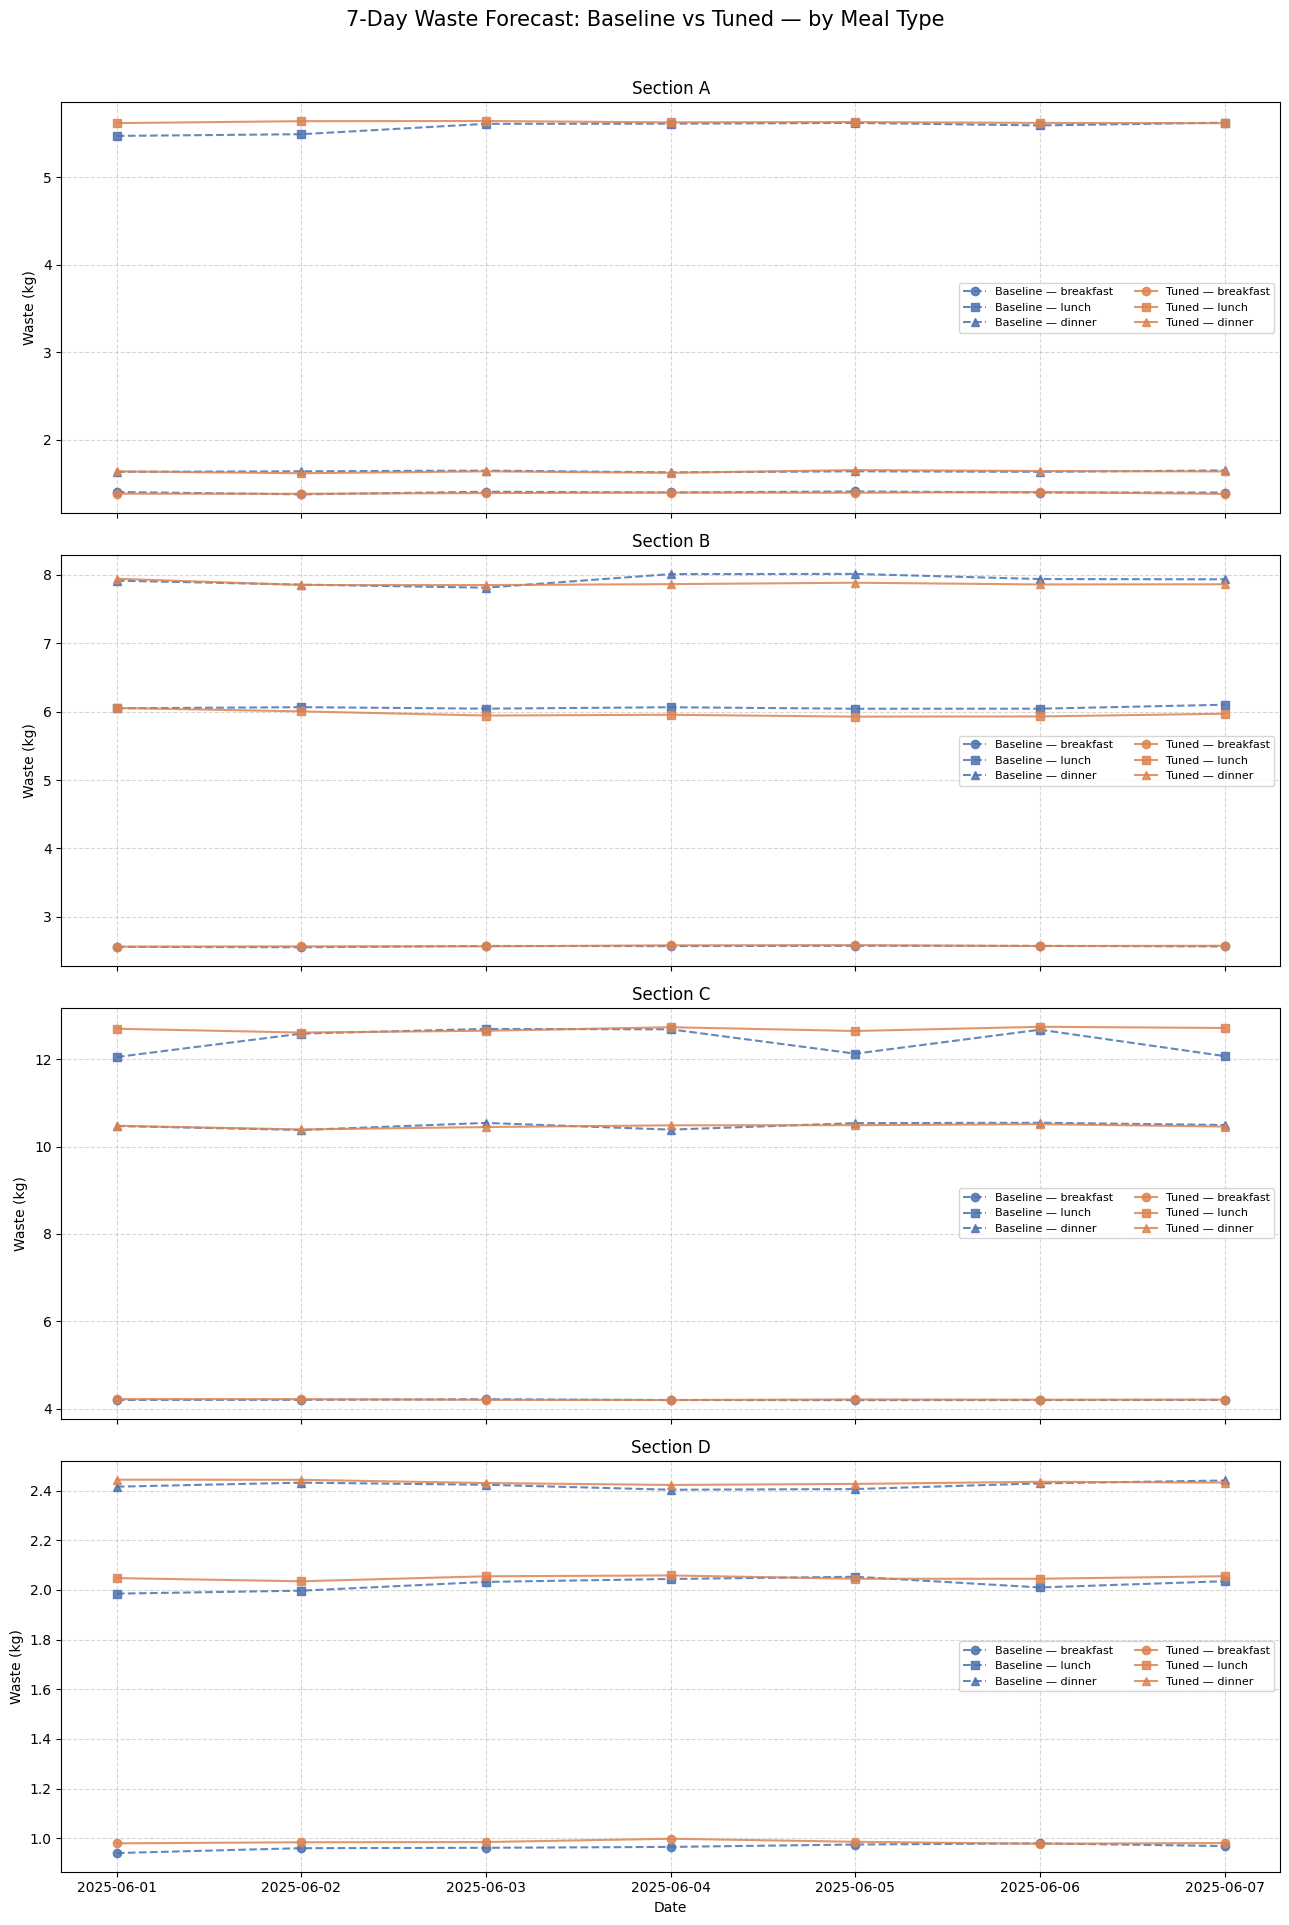

In [18]:
meal_styles = {'breakfast': 'o', 'lunch': 's', 'dinner': '^'}
model_palette = {'Baseline': '#4C72B0', 'Tuned': '#DD8452'}

fig, axes = plt.subplots(len(sections), 1, figsize=(13, 5 * len(sections)), sharex=True)
fig.suptitle('7-Day Waste Forecast: Baseline vs Tuned — by Meal Type', fontsize=15)

if len(sections) == 1:
    axes = [axes]

for i, sec_key in enumerate(sections):
    ax = axes[i]
    sec_plot = forecast_df_plot[forecast_df_plot['Section'] == sec_key.upper()]

    for model_name in ['Baseline', 'Tuned']:
        for meal in MEALS:
            subset = sec_plot[(sec_plot['Model'] == model_name) & (sec_plot['Meal'] == meal)]
            ax.plot(
                subset['Date'], subset['Forecast'],
                marker=meal_styles[meal],
                color=model_palette[model_name],
                linestyle='-' if model_name == 'Tuned' else '--',
                alpha=0.85,
                label=f'{model_name} — {meal}'
            )

    ax.set_title(f'Section {sec_key.upper()}')
    ax.set_ylabel('Waste (kg)')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(fontsize=8, ncol=2)

axes[-1].set_xlabel('Date')
plt.tight_layout(rect=[0, 0.02, 1, 0.97])
plt.show()

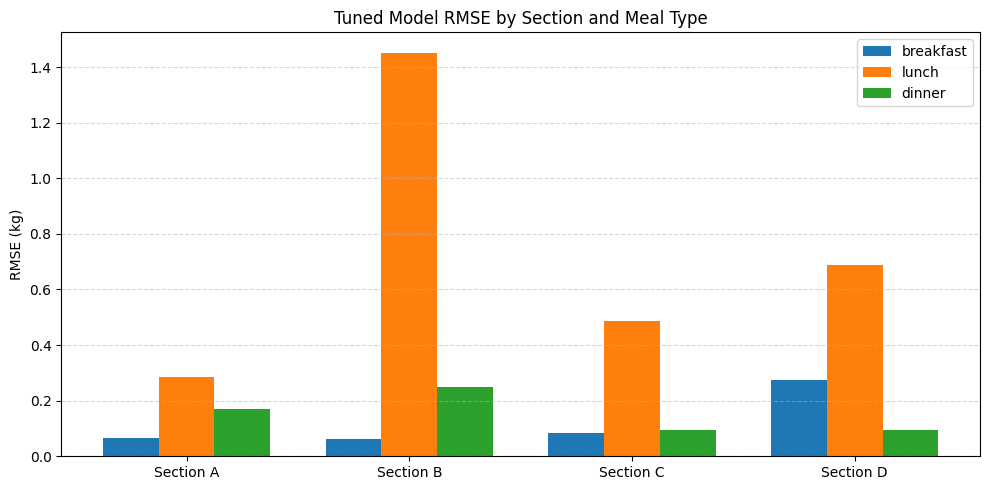

In [19]:
# Bar chart: tuned model RMSE per section and meal
meal_metrics = results_df[
    (results_df['model'] == 'Tuned (Optuna)') & (results_df['meal'] != 'overall')
].copy()

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(sections))
width = 0.25
for j, meal in enumerate(MEALS):
    vals = [meal_metrics[(meal_metrics['section'] == s.upper()) & (meal_metrics['meal'] == meal)]['RMSE'].values
            for s in sections]
    vals = [v[0] if len(v) else 0 for v in vals]
    ax.bar(x + j * width, vals, width, label=meal)

ax.set_xticks(x + width)
ax.set_xticklabels([f'Section {s.upper()}' for s in sections])
ax.set_ylabel('RMSE (kg)')
ax.set_title('Tuned Model RMSE by Section and Meal Type')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()